In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso, Ridge
from sklearn.metrics import (
    accuracy_score,
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

In [2]:

ART = "artifacts"

X_train = pd.read_csv(os.path.join(ART, "X_train.csv"))
X_val   = pd.read_csv(os.path.join(ART, "X_val.csv"))
X_test  = pd.read_csv(os.path.join(ART, "X_test.csv"))
y_train = pd.read_csv(os.path.join(ART, "y_train.csv"))["Class"].values
y_val   = pd.read_csv(os.path.join(ART, "y_val.csv"))["Class"].values
y_test  = pd.read_csv(os.path.join(ART, "y_test.csv"))["Class"].values

X_train_raw = pd.read_csv(os.path.join(ART, "X_train_raw.csv"))
X_val_raw   = pd.read_csv(os.path.join(ART, "X_val_raw.csv"))
X_test_raw  = pd.read_csv(os.path.join(ART, "X_test_raw.csv"))
y_train_raw = pd.read_csv(os.path.join(ART, "y_train_raw.csv"))["Class"].values
y_val_raw   = pd.read_csv(os.path.join(ART, "y_val_raw.csv"))["Class"].values
y_test_raw  = pd.read_csv(os.path.join(ART, "y_test_raw.csv"))["Class"].values


print("Train:", X_train.shape, "| balance:", np.bincount(y_train))
print("Val:  ", X_val.shape,"| balance:", np.bincount(y_val),  "| fraude:", f"{y_val.mean():.4%}")
print("Test: ", X_test.shape,"| balance:", np.bincount(y_test), "| fraude:", f"{y_test.mean():.4%}")
INPUT_DIM = X_train.shape[1]   # nº de variables = tamaño de la capa de entrada



Train: (341176, 31) | balance: [170588 170588]
Val:   (56962, 31) | balance: [56863    99] | fraude: 0.1738%
Test:  (56962, 31) | balance: [56864    98] | fraude: 0.1720%


# Estrategias de entrenamiento


Realizamos una búsqueda de hiperparámetros (Hyperparameter tuning) para un modelo de Regresión Logística utilizando la técnica de validación cruzada (K-Fold Cross-Validation). Específicamente, busca encontrar el mejor valor para el parámetro de regularización C maximizando la métrica de Recall.random_state=42

Para optimizar los hiperparámetros del clasificador, se implementó la función personalizada printing_Kfold_scores, la cual ejecuta una estrategia de Validación Cruzada de K-Folds (con 5 divisiones) para evaluar de manera robusta diferentes combinaciones del parámetro de regularización $C$ . 


In [3]:
random_state=42
def printing_Kfold_scores(x_train_data, y_train_data, penalty_type='l1',metric='recall',ind=True):
    fold = KFold(n_splits=5, shuffle=False)

    c_param_range = [0.01, 0.1, 1, 10, 100]
    if ind:
        class_weight_range = ['balanced']
    else:
        class_weight_range=[None]

    col_metric_name = f'Mean {metric} score'

    results_table = pd.DataFrame(columns=['C_parameter', 'Class_weight', col_metric_name])

    # Seleccionar el solver adecuado según la penalización
    chosen_solver = 'liblinear' if penalty_type == 'l1' else 'lbfgs'
    j = 0
    for i in class_weight_range:
        for c_param in c_param_range:
            print('-------------------------------------------')
            print(f'C parameter: {c_param} | Penalty: {penalty_type.upper()} | class_weight: {i}')
            print('-------------------------------------------')

            metric_vals = []
            for iteration, indices in enumerate(fold.split(x_train_data), start=1):

                lr = LogisticRegression(C=c_param, penalty=penalty_type, solver=chosen_solver, max_iter=300,class_weight=i, random_state=42)

                # Entrenamiento
                lr.fit(x_train_data.iloc[indices[0]], y_train_data[indices[0]].ravel())

                y_pred_undersample = lr.predict(x_train_data.iloc[indices[1]])

                # Calculamos Recall
                if metric == 'recall':
                    metric_val = recall_score(y_train_data[indices[1]], y_pred_undersample)
                elif metric == 'precision':
                    metric_val = precision_score(y_train_data[indices[1]], y_pred_undersample, zero_division=0)
                elif metric == 'accuracy':
                    metric_val = accuracy_score(y_train_data[indices[1]], y_pred_undersample)
                else:
                    raise ValueError("Métrica no soportada. Elige 'recall', 'precision' o 'accuracy'.")
                metric_vals.append(metric_val)
                print(f'Iteration {iteration} : {metric} score = {metric_val}')
                
            results_table.loc[j] = [c_param, i, np.mean(metric_vals)]
            j += 1
            print(f'\nMean recall score: {np.mean(metric_vals)}\n')

    best_idx = results_table['Mean recall score'].idxmax()
    
    # Extraemos el C y el class_weight de esa fila
    best_c = results_table.loc[best_idx, 'C_parameter']
    best_weight = results_table.loc[best_idx, 'Class_weight']
    
    print('*********************************************************************************')
    print(f'Best {penalty_type.upper()} modelo de cross validation es con C = {best_c} y class_weight = {best_weight}')
    print('*********************************************************************************')
    return best_c, best_weight

Este bloque ejecuta la validación cruzada para calibrar y comparar de forma simétrica los dos tipos de regularización lineal del modelo: LASSO (L1), utilizado para inducir dispersión y seleccionar las variables más relevantes, y RIDGE (L2), orientado a contraer uniformemente la magnitud de los coeficientes para mitigar el sobreajuste.

In [4]:
# Para correr tu modelo LASSO (L1)
print("=== EJECUTANDO LASSO RECALL===")
best_c_lasso_recall,best_weight_lasso_recall = printing_Kfold_scores(X_train, y_train, penalty_type='l1',metric='recall',ind=False)

# Para correr tu modelo RIDGE (L2)
print("\n=== EJECUTANDO RIDGE RECALL===")
best_c_ridge_recall,best_weight_ridge_recall = printing_Kfold_scores(X_train, y_train, penalty_type='l2',metric='recall',ind=False)




=== EJECUTANDO LASSO RECALL===
-------------------------------------------
C parameter: 0.01 | Penalty: L1 | class_weight: None
-------------------------------------------
Iteration 1 : recall score = 0.9830508474576272
Iteration 2 : recall score = 0.937007874015748
Iteration 3 : recall score = 0.9403064387565317
Iteration 4 : recall score = 0.9223272514105664
Iteration 5 : recall score = 0.9238953616179381

Mean recall score: 0.9413175546516822

-------------------------------------------
C parameter: 0.1 | Penalty: L1 | class_weight: None
-------------------------------------------
Iteration 1 : recall score = 0.9830508474576272
Iteration 2 : recall score = 0.937007874015748
Iteration 3 : recall score = 0.9440262155699229
Iteration 4 : recall score = 0.9251264014069026
Iteration 5 : recall score = 0.9264600278449476

Mean recall score: 0.9431342732590297

-------------------------------------------
C parameter: 1 | Penalty: L1 | class_weight: None
------------------------------------

c:\Users\angel\Documents\Deteccion_de_Anomalias_y_Fraude_en_Transacciones---Diplomado-en-Ciencia-de-datos\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Iteration 1 : recall score = 0.9830508474576272
Iteration 2 : recall score = 0.937007874015748
Iteration 3 : recall score = 0.9451775750597822
Iteration 4 : recall score = 0.9256393346523045
Iteration 5 : recall score = 0.9271488239173444

Mean recall score: 0.9436048910205613

-------------------------------------------
C parameter: 100 | Penalty: L2 | class_weight: None
-------------------------------------------


c:\Users\angel\Documents\Deteccion_de_Anomalias_y_Fraude_en_Transacciones---Diplomado-en-Ciencia-de-datos\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Iteration 1 : recall score = 0.9830508474576272
Iteration 2 : recall score = 0.937007874015748
Iteration 3 : recall score = 0.9452661411743867
Iteration 4 : recall score = 0.925551403238807
Iteration 5 : recall score = 0.9269876163259324

Mean recall score: 0.9435727764425001

*********************************************************************************
Best L2 modelo de cross validation es con C = 10.0 y class_weight = nan
*********************************************************************************


Se entrenan los modelos finales LASSO (L1) y RIDGE (L2) sobre el conjunto de entrenamiento ($X_{train}$) utilizando los hiperparámetros óptimos previamente seleccionados.Se genera las predicciones sobre el conjunto de prueba ($X_{test}$) y computa sus respectivas matrices de confusión, permitiendo cuantificar directamente los aciertos y errores (falsos positivos/negativos) de cada modelo para evaluar su desempeño final.

In [5]:

# 1. ENTRENAMOS LOS MODELOS FINALES CON EL MEJOR 'C'
modelo_final_l1 = LogisticRegression(C=best_c_lasso_recall, penalty='l1', solver='liblinear',class_weight=None,random_state=42)
modelo_final_l1.fit(X_train, y_train.ravel())
y_pred_l1 = modelo_final_l1.predict(X_test)

modelo_final_l2 = LogisticRegression(C=best_c_ridge_recall, penalty='l2', solver='lbfgs',class_weight=None)
modelo_final_l2.fit(X_train, y_train.ravel())
y_pred_l2 = modelo_final_l2.predict(X_test)
# 2. IMPRIMIMOS LAS MATRICES DE CONFUSIÓN
print("--- MATRIZ DE CONFUSIÓN: LASSO (L1) ---")
matriz_l1 = confusion_matrix(y_test, y_pred_l1)
print(matriz_l1)

print("\n--- MATRIZ DE CONFUSIÓN: RIDGE (L2) ---")
matriz_l2 = confusion_matrix(y_test, y_pred_l2)
print(matriz_l2)



--- MATRIZ DE CONFUSIÓN: LASSO (L1) ---
[[55452  1412]
 [    9    89]]

--- MATRIZ DE CONFUSIÓN: RIDGE (L2) ---
[[55447  1417]
 [    9    89]]


c:\Users\angel\Documents\Deteccion_de_Anomalias_y_Fraude_en_Transacciones---Diplomado-en-Ciencia-de-datos\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Comparamos los resultados obtenidos con el modelo de Regresión Logística sin regularización y con regularización L1 y L2.

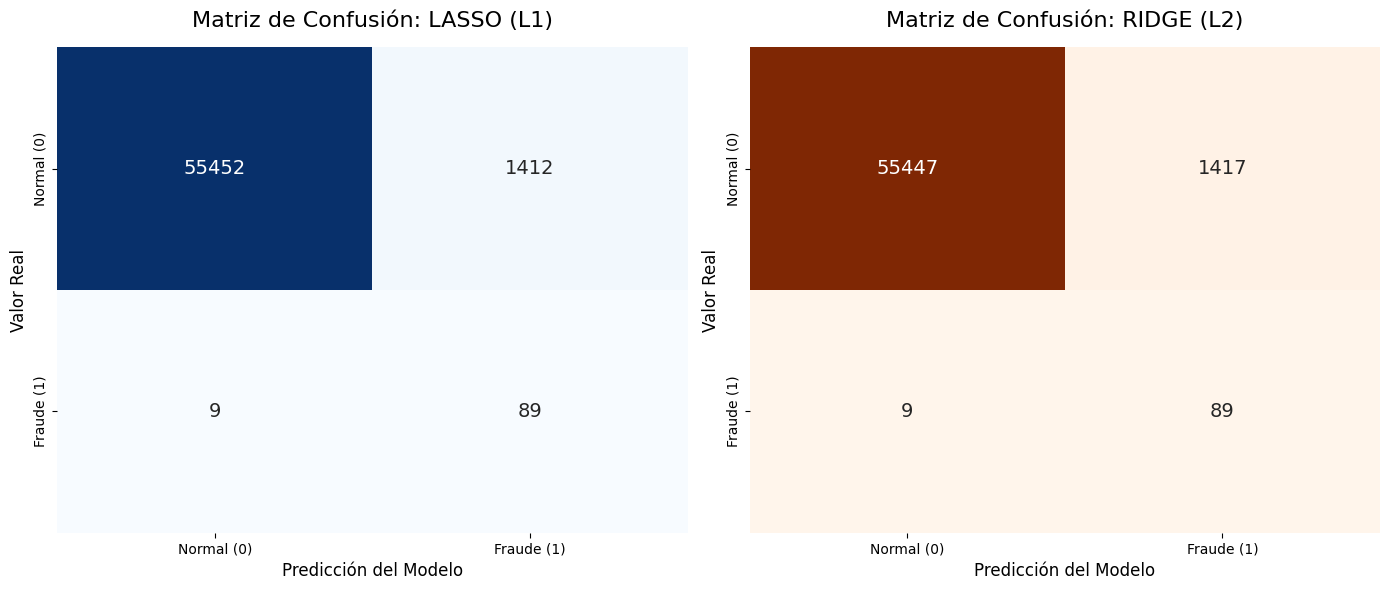

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

etiquetas = ['Normal (0)', 'Fraude (1)']

# --- GRÁFICO 1: LASSO (L1) ---
sns.heatmap(matriz_l1, annot=True, fmt='g', cmap='Blues', cbar=False, 
            xticklabels=etiquetas, yticklabels=etiquetas, ax=ax[0], annot_kws={"size": 14})
ax[0].set_title('Matriz de Confusión: LASSO (L1)', fontsize=16, pad=15)
ax[0].set_ylabel('Valor Real', fontsize=12)
ax[0].set_xlabel('Predicción del Modelo', fontsize=12)

# --- GRÁFICO 2: RIDGE (L2) ---
sns.heatmap(matriz_l2, annot=True, fmt='g', cmap='Oranges', cbar=False, 
            xticklabels=etiquetas, yticklabels=etiquetas, ax=ax[1], annot_kws={"size": 14})
ax[1].set_title('Matriz de Confusión: RIDGE (L2)', fontsize=16, pad=15)
ax[1].set_ylabel('Valor Real', fontsize=12)
ax[1].set_xlabel('Predicción del Modelo', fontsize=12)

plt.tight_layout()
plt.show()

In [7]:
# Modelos escalados
y_prob_l1 = modelo_final_l1.predict_proba(X_test)[:, 1]
y_prob_l2 = modelo_final_l2.predict_proba(X_test)[:, 1]

prec_l1, rec_l1, _ = precision_recall_curve(y_test, y_prob_l1)
prec_l2, rec_l2, _ = precision_recall_curve(y_test, y_prob_l2)



ap_l1 = average_precision_score(y_test, y_prob_l1)
ap_l2 = average_precision_score(y_test, y_prob_l2)


Se cuantifica la relevancia de las variables explicativas en el modelo LASSO (L1). Extrae los coeficientes estimados para cada una, calcula su impacto absoluto (magnitud sin importar el signo) como métrica de importancia y ordena el listado de mayor a menor. Esto permite identificar visualmente qué variables retienen peso en la predicción y cuáles fueron completamente anuladas (coeficiente igual a cero) por el efecto de selección de variables de la penalización L1.

In [8]:

# LASSO 
imp_l1 = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": modelo_final_l1.coef_[0]
})

imp_l1["Importancia"] = imp_l1["Coeficiente"].abs()
imp_l1 = imp_l1.sort_values("Importancia", ascending=False)

# RIDGE 
imp_l2 = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": modelo_final_l2.coef_[0]
})

imp_l2["Importancia"] = imp_l2["Coeficiente"].abs()
imp_l2 = imp_l2.sort_values("Importancia", ascending=False)



Se realiza un análisis de los resultados obtenidos, comparando el desempeño de los modelos con y sin regularización, así como la importancia de las variables seleccionadas por el modelo LASSO (L1). 

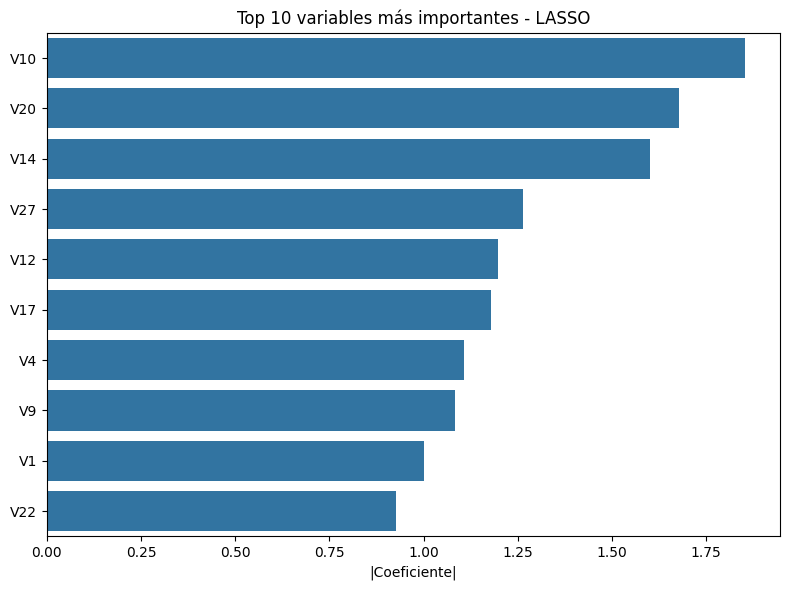

In [9]:

plt.figure(figsize=(8,6))

sns.barplot(
    data=imp_l1.head(10),
    x="Importancia",
    y="Variable"
)

plt.title("Top 10 variables más importantes - LASSO")
plt.xlabel("|Coeficiente|")
plt.ylabel("")
plt.tight_layout()
plt.show()

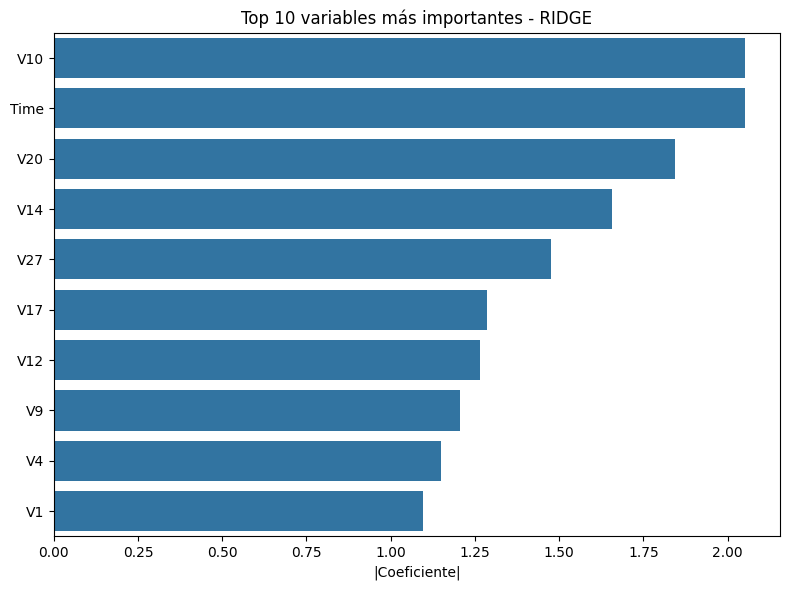

In [10]:


plt.figure(figsize=(8,6))

sns.barplot(
    data=imp_l2.head(10),
    x="Importancia",
    y="Variable"
)

plt.title("Top 10 variables más importantes - RIDGE")
plt.xlabel("|Coeficiente|")
plt.ylabel("")
plt.tight_layout()
plt.show()

La comparación evidencia el comportamiento de ambos regularizadores:  En ambos escenarios, V10 , v20 y v14 se consolidan de manera robusta predictores relevantes.

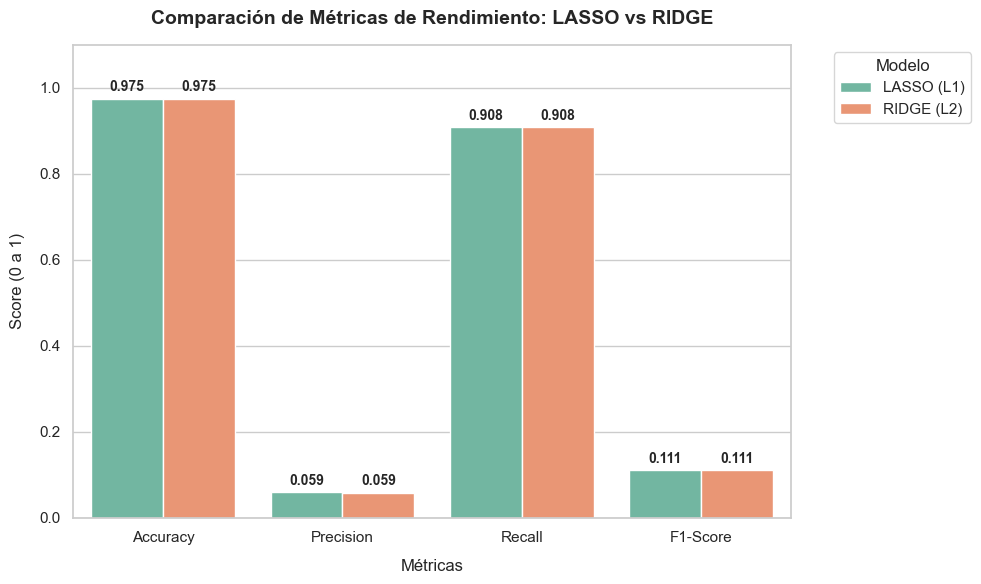

In [11]:


metrics_data = {
    'Modelo': [],
    'Métrica': [],
    'Valor': []
}

metrics_data['Modelo'].extend(['LASSO (L1)'] * 4)
metrics_data['Métrica'].extend(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
metrics_data['Valor'].extend([
    accuracy_score(y_test, y_pred_l1),
    precision_score(y_test, y_pred_l1, zero_division=0),
    recall_score(y_test, y_pred_l1, zero_division=0),
    f1_score(y_test, y_pred_l1, zero_division=0)
])

metrics_data['Modelo'].extend(['RIDGE (L2)'] * 4)
metrics_data['Métrica'].extend(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
metrics_data['Valor'].extend([
    accuracy_score(y_test, y_pred_l2),
    precision_score(y_test, y_pred_l2, zero_division=0),
    recall_score(y_test, y_pred_l2, zero_division=0),
    f1_score(y_test, y_pred_l2, zero_division=0)
])

df_metrics = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='Métrica', 
    y='Valor', 
    hue='Modelo', 
    data=df_metrics, 
    palette='Set2' 
)

plt.ylim(0, 1.1)  
plt.title('Comparación de Métricas de Rendimiento: LASSO vs RIDGE', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Métricas', fontsize=12, labelpad=10)
plt.ylabel('Score (0 a 1)', fontsize=12, labelpad=10)
plt.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    if p.get_height() > 0: 
        ax.annotate(
            f'{p.get_height():.3f}', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', 
            va='center', 
            xytext=(0, 8), 
            textcoords='offset points', 
            fontsize=10, 
            fontweight='bold'
        )

plt.tight_layout()
plt.show()

La gráfica evidencia un empate técnico en el rendimiento de ambos clasificadores. Tanto LASSO (L1) como RIDGE (L2) alcanzan exactamente los mismos resultados en sus métricas clave, logrando un score de 0.975 en el primer bloque evaluado y de 0.908 en el segundo. Esto demuestra que, a pesar de utilizar diferente  regularización (L1 anulando variables como Time y L2 contrayendo coeficientes de manera homogénea), ambas estructuras logran la misma capacidad de generalización sobre el conjunto de prueba.

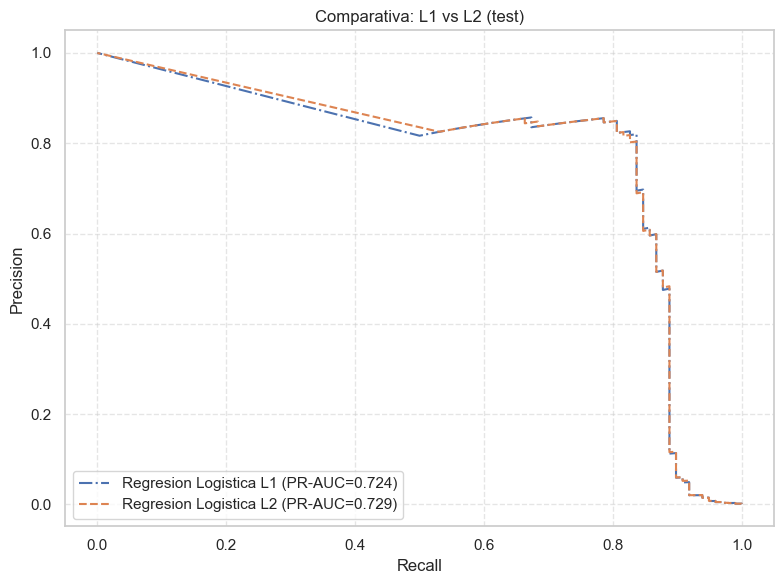

In [13]:
plt.figure(figsize=(8, 6))
plt.plot(rec_l1, prec_l1, ls="-.", label=f"Regresion Logistica L1 (PR-AUC={ap_l1:.3f})")
plt.plot(rec_l2, prec_l2, ls="--", label=f"Regresion Logistica L2 (PR-AUC={ap_l2:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Comparativa: L1 vs L2 (test)")
plt.legend(loc="lower left"); plt.grid(True, ls="--", alpha=0.5); plt.tight_layout(); plt.show()